In [1]:
import json
import os
import re
from collections import Counter


def load_json_file(filepath):
    """Load a JSON file"""
    with open(filepath, 'r') as f:
        return json.load(f)

def clean_boundaries(text, start, end):
    """Remove speaker/listener prefixes and dots from span boundaries"""
    
    # Updated prefix pattern to include 'listner'
    prefix_pattern = r'^(speaker|listener)\s*:?\s*'
    
    # Find new start index
    new_start = start
    for i in range(start, end):
        if text[i] not in ' ,.~':
            new_start = i
            break
    
    # Find new end index
    new_end = end
    for i in range(end-1, start-1, -1):
        if text[i] not in ' ,.~':
            new_end = i + 1
            break
    
    # Remove prefix if present
    remaining_text = text[new_start:new_end]
    match = re.match(prefix_pattern, remaining_text, re.IGNORECASE)
    if match:
        new_start += len(match.group())
        # Trim again leading dots/spaces/tilde
        for i in range(new_start, new_end):
            if text[i] not in ' ,.~':
                new_start = i
                break
    
    return new_start, new_end



def extract_annotations(data_folder, exclude=[]):
    """ Extract annotations from all JSON files across all annotator folders.
    """
    all_rounds = {}  # (game_id, round_num) -> {annotator -> [spans]}
    all_texts = {}   # (game_id, round_num) -> text

    print("Loading")

    # Get all annotator folders
    annotator_folders = []
    for item in os.listdir(data_folder):
        if item not in exclude:
            folder_path = os.path.join(data_folder, item)
            if os.path.isdir(folder_path):
                annotator_folders.append(item)

    print(f"Found {len(annotator_folders)} annotators: {annotator_folders}")

    # Process each annotator
    for annotator in annotator_folders:
        annotator_path = os.path.join(data_folder, annotator)
        json_files = [f for f in os.listdir(annotator_path) if f.lower().endswith('.json')]

        print(f"  {annotator}: {len(json_files)} files")

        for json_file in json_files:
            filepath = os.path.join(annotator_path, json_file)

            try:
                data = load_json_file(filepath)  
                if not isinstance(data, list):
                    data = [data]

                for item in data:
                    meta = item.get('meta', {})
                    game_id = meta.get('game_id')
                    round_num = meta.get('round_num')
                    if not game_id or round_num is None:
                        continue
                    round_key = (game_id, round_num)

                    text_data = item.get('data', {})
                    text = text_data.get('text', '')
                    prev_text = all_texts.get(round_key)
                    if prev_text is None:
                        all_texts[round_key] = text
                    elif prev_text != text:
                        print(f"WARNING: text mismatch for {round_key}")

                    annotations = item.get('annotations', [])
                    spans = []

                    for annotation in annotations:
                        # Skip cancelled annotations
                        if annotation.get('was_cancelled', False):
                            continue

                        is_gt = annotation.get('ground_truth', False)
                        results = annotation.get('result', [])

                        for result in results:
                            value = result.get('value', {})
                            if 'start' in value and 'end' in value and 'labels' in value:
                                span = {
                                    'start': int(value['start']),
                                    'end': int(value['end']),
                                    'text': value.get('text', ''),
                                    'labels': value.get('labels', []),
                                    #'ground_truth': is_gt,
                                }
                                spans.append(span)

                    if spans:
                        round_bucket = all_rounds.setdefault(round_key, {})
                        round_bucket.setdefault(annotator, []).extend(spans)

            except Exception as e:
                print(f"Error reading {json_file}: {e}")

    total_spans = sum(len(spans) for round_data in all_rounds.values()
                      for spans in round_data.values())
    print(f"Loaded {len(all_rounds)} rounds with {total_spans} total spans")

    return all_rounds, all_texts

def calculate_pairwise_agreement(all_rounds, all_texts, use_clean_boundaries=False):
    """Calculate pairwise agreement between annotators"""
    pass
    

def calculate_majority_stats(all_rounds, all_texts, use_clean_boundaries=False):
    """
    majority across 3 annotators, boundary-only and label-aware.
    """
    total_span_positions = 0

    # Boundary-only
    perfect_3_boundary = 0   
    majority_2_boundary = 0  
    singleton = 0           

    # Label-aware (exact label-set at the same boundary)
    perfect_3_labels = 0     
    majority_2_labels = 0    # exactly 2 share identical label sets (not 3)

    for round_key, annotators in all_rounds.items():
        
        text = all_texts.get(round_key, '')

        # Build annotator -> {(start,end): set(labels)}, merging labels per boundary
        all_spans = {}
        for ann, spans in annotators.items():
            bmap = all_spans.setdefault(ann, {})
            for span in spans:
                start, end = span['start'], span['end']
                if use_clean_boundaries:
                    start, end = clean_boundaries(text, start, end)
                if start >= end:
                    continue  # skip degenerate spans
                key = (start, end)
                bmap.setdefault(key, set()).update(span.get('labels', []))

        # Union of boundaries in this round
        all_positions = set()
        for bmap in all_spans.values():
            all_positions.update(bmap.keys())
       

        for position in all_positions:
            total_span_positions += 1

            who_marked = [ann for ann, bmap in all_spans.items() if position in bmap]
            #print(who_marked)
            k = len(who_marked)

            # boundary-only 
            if k == 3:
                perfect_3_boundary += 1
            elif k == 2:
                majority_2_boundary += 1
            else:
                singleton += 1  # k == 1
  
            # label-aware
            if k >= 2:
                # Compare exact label sets per annotator at this boundary
                label_sets = [frozenset(all_spans[ann][position]) for ann in who_marked]
                counts = Counter(label_sets)
                top_count = counts.most_common(1)[0][1]

                if k == 3 and len(counts) == 1:
                    # all three have identical label sets
                    perfect_3_labels += 1
                elif top_count == 2:
                    # exactly one label-set has 2 votes (majority)
                    majority_2_labels += 1
        

    denom = total_span_positions

    return {
        # Universe
        'total_positions': total_span_positions,

        # Boundary-only
        'perfect_3_boundary': perfect_3_boundary,
        'majority_2_boundary': majority_2_boundary,   
        'singleton': singleton,                       
        'perfect_boundary_pct': 100.0 * perfect_3_boundary / denom,
        'majority_boundary_pct': 100.0 * (perfect_3_boundary + majority_2_boundary) / denom,  

        # Label-aware
        'perfect_3_labels': perfect_3_labels,         
        'majority_2_labels': majority_2_labels,      
        'perfect_labels_pct': 100.0 * perfect_3_labels / denom,
        'majority_labels_pct': 100.0 * (perfect_3_labels + majority_2_labels) / denom,        
    }


def print_majority(name, stats):
    tot = stats['total_positions'] or 1
    print(f"\nresults — {name}")

    # Boundary-only
    print("Boundary-only:")
    print(f"  Perfect (3/3): {stats['perfect_boundary_pct']:.1f}% "
          f"({stats['perfect_3_boundary']}/{stats['total_positions']})")
    print(f"  Majority (2+/3): {stats['majority_boundary_pct']:.1f}% "
          f"({stats['perfect_3_boundary'] + stats['majority_2_boundary']}/{stats['total_positions']})")
    print(f"  Single (1/3): {100.0 * stats['singleton']/tot:.1f}% "
          f"({stats['singleton']}/{stats['total_positions']})")

    # Label-aware
    print("Label-aware:")
    print(f"  Perfect (3/3): {stats['perfect_labels_pct']:.1f}% "
          f"({stats['perfect_3_labels']}/{stats['total_positions']})")
    print(f"  Majority (2+/3): {stats['majority_labels_pct']:.1f}% "
          f"({stats['perfect_3_labels'] + stats['majority_2_labels']}/{stats['total_positions']})")

def run_analysis(data_folder, exclude=[]):
    """Run the complete IAA analysis"""
    
    # Extract all annotations
    all_rounds, all_texts = extract_annotations(data_folder, exclude=exclude)
    
    if not all_rounds:
        print("No annotation data found!")
        return
   # Print results
    maj_strict = calculate_majority_stats(all_rounds, all_texts, False)
    maj_soft = calculate_majority_stats(all_rounds, all_texts, True)

    print_majority("original boundaries", maj_strict)
    print_majority("cleaned boundaries", maj_soft)



In [2]:
# Change this path to your data folder
data_folder = "data/raw_annotations"
    
results = run_analysis(data_folder)

Loading
Found 3 annotators: ['Ann_C', 'Ann_A', 'Ann_B']
  Ann_C: 25 files
  Ann_A: 25 files
  Ann_B: 25 files
Loaded 1500 rounds with 15444 total spans

results — original boundaries
Boundary-only:
  Perfect (3/3): 49.4% (1362/2755)
  Majority (2+/3): 68.5% (1886/2755)
  Single (1/3): 31.5% (869/2755)
Label-aware:
  Perfect (3/3): 40.4% (1114/2755)
  Majority (2+/3): 64.1% (1765/2755)

results — cleaned boundaries
Boundary-only:
  Perfect (3/3): 59.6% (1475/2475)
  Majority (2+/3): 82.9% (2053/2475)
  Single (1/3): 17.1% (422/2475)
Label-aware:
  Perfect (3/3): 48.5% (1201/2475)
  Majority (2+/3): 78.3% (1938/2475)


In [3]:
def parse_targets_from_labels(labels):
    """Extract target indices [1..9] from labels like 't1','t2',..."""
    targets = []
    for lab in labels:
        if isinstance(lab, str) and lab.startswith('t') and lab[1:].isdigit():
            n = int(lab[1:])
            if 1 <= n <= 9:
                targets.append(n)
    return sorted(set(targets))

def build_label_aware_majority_consensus(all_rounds, all_texts, use_clean_boundaries=False, add_consensus_labels=False, return_all_positions=False, return_all_labels=False):
    """
    Build label-aware majority consensus at exact (start,end) spans.
    Returns a list of consensus dicts (see schema above).
    """
    consensus = []

    for round_key, annotators in all_rounds.items():
        game_id, round_num = round_key if isinstance(round_key, tuple) else (round_key, None)
        if len(annotators) < 2:
            continue

        text = all_texts.get(round_key, "") or ""
        # 1) per-annotator map: (start,end) -> set(labels)
        all_spans = {}
        for ann, spans in annotators.items():
            bmap = all_spans.setdefault(ann, {})
            for span in spans:
                start, end = int(span['start']), int(span['end'])
                if use_clean_boundaries:
                    start, end = clean_boundaries(text, start, end)
                if start >= end:
                    continue
                key = (start, end)
                bmap.setdefault(key, set()).update(span.get('labels', []))

        all_positions = set()
        for bmap in all_spans.values():
            all_positions.update(bmap.keys())

        for position in all_positions:
            who_marked = [ann for ann, bmap in all_spans.items() if position in bmap]
            if len(who_marked) < 2 and not return_all_positions:
                # if no majority agreed on span
                continue

            label_sets = [frozenset(all_spans[ann][position]) for ann in who_marked]
            counts = Counter(label_sets)
            top_labelset, top_votes = counts.most_common(1)[0]
            #print(top_labelset, top_votes, position, who_marked)

            start, end = position
            span_text = text[start:end] if 0 <= start <= end <= len(text) else ""
            
            if top_votes >= 2 or return_all_labels:  
                # majority on exact label set
                supporters = [ann for ann in who_marked if frozenset(all_spans[ann][position]) == top_labelset]
                
            else:
                # no majority agreed on labels: 
                if not add_consensus_labels:
                    continue
                # select "consensus", i.e., the labels all annotators for the given span agree on
                # mark 'unclear_location_reference' if no such label set exists
                consensus_set = frozenset.intersection(*[l for l in label_sets])
                if len(consensus_set) < 2:  # no consensus or only 'with_reference'
                    consensus_set = frozenset({'unclear_location_reference'})
                top_labelset = consensus_set
                
                supporters = ['consensus']
                
            record = {
                "game_id": game_id,
                "round_num": round_num,
                "start": start,
                "end": end,
                "span_text": span_text,
                "n_marked": len(who_marked),
                "votes_for_labelset": top_votes,
                "label_set": sorted(top_labelset),
                "annotators_supporting": sorted(supporters),
                "targets": parse_targets_from_labels(top_labelset),
                "is_perfect_labels": (top_votes == len(who_marked)),
                "cleaned": bool(use_clean_boundaries),
            }
                            
            consensus.append(record)

    return consensus

Loading
Found 3 annotators: ['Ann_C', 'Ann_A', 'Ann_B']
  Ann_C: 25 files
  Ann_A: 25 files
  Ann_B: 25 files
Loaded 1500 rounds with 15444 total spans
Saved 1765 consensus items → data/processed_annotations/consensus_majority_raw.json
Saved 2053 consensus items → data/processed_annotations/consensus_majority_clean.json
3x3 grid counts: [[375, 319, 361], [206, 370, 187], [218, 187, 248]]


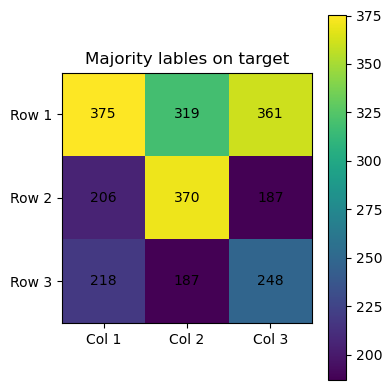

In [4]:
from pathlib import Path
GRID_POS = {
    1: (0, 0), 2: (0, 1), 3: (0, 2),
    4: (1, 0), 5: (1, 1), 6: (1, 2),
    7: (2, 0), 8: (2, 1), 9: (2, 2),
}

def save_consensus_json(consensus, out_path):
    out_path = Path(out_path)
    out_path.parent.mkdir(parents=True, exist_ok=True)
    with out_path.open("w", encoding="utf-8") as f:
        json.dump(consensus, f, ensure_ascii=False, indent=2)
    print(f"Saved {len(consensus)} consensus items → {out_path}")

def build_simple_target_heatmap(consensus):
    """
    Aggregate targets to a 3x3 grid count.
    """
    grid = [[0 for _ in range(3)] for _ in range(3)]
    for item in consensus:
        for t in item.get("targets", []):
            r, c = GRID_POS[t]
            grid[r][c] += 1
    return grid


all_rounds, all_texts = extract_annotations(data_folder, exclude=['gpt-5mini'])  # extract annotations from previous script

consensus_raw = build_label_aware_majority_consensus(all_rounds, all_texts, use_clean_boundaries=False)
save_consensus_json(consensus_raw, "data/processed_annotations/consensus_majority_raw.json")
consensus_clean = build_label_aware_majority_consensus(all_rounds, all_texts, use_clean_boundaries=True, add_consensus_labels=True)
save_consensus_json(consensus_clean, "data/processed_annotations/consensus_majority_clean.json")

grid_counts = build_simple_target_heatmap(consensus_clean)  # or consensus_raw
print("3x3 grid counts:", grid_counts)

import matplotlib.pyplot as plt
import numpy as np
fig, ax = plt.subplots(figsize=(4,4))
arr = np.array(grid_counts)
im = ax.imshow(arr)
for i in range(3):
    for j in range(3):
        ax.text(j, i, arr[i, j], ha="center", va="center")
ax.set_xticks([0,1,2]); ax.set_yticks([0,1,2])
ax.set_xticklabels(["Col 1","Col 2","Col 3"])
ax.set_yticklabels(["Row 1","Row 2","Row 3"])
ax.set_title("Majority lables on target")
plt.colorbar(im, ax=ax); plt.tight_layout(); plt.show()

In [5]:
from collections import Counter

label_combination_counts = Counter([
    tuple(sorted(x['targets'])) for x in consensus_clean
])

combination_freqs = dict(
    (c, counts/len(consensus_clean)) for c, counts in label_combination_counts.items()
    if len(c) >= 2
)

sorted_combination_freqs = sorted(combination_freqs.items(), key=lambda x:x[1], reverse=True)

for k,v in sorted_combination_freqs[:25]:
    comb = '|'.join([str(x) for x in k])
    freq = round(v * 100, 2)
    print(f'{comb.ljust(8)}---    {freq} %')

1|2|3   ---    2.97 %
7|8|9   ---    1.22 %
1|3     ---    0.83 %
4|5|6   ---    0.78 %
1|2     ---    0.68 %
1|4|7   ---    0.63 %
3|6     ---    0.54 %
2|5|8   ---    0.54 %
7|8     ---    0.54 %
2|3     ---    0.49 %
5|6     ---    0.49 %
4|7     ---    0.49 %
2|5     ---    0.44 %
8|9     ---    0.44 %
4|5     ---    0.39 %
4|6     ---    0.39 %
5|8     ---    0.39 %
3|6|9   ---    0.39 %
3|9     ---    0.34 %
6|9     ---    0.34 %
1|4     ---    0.29 %
2|8     ---    0.29 %
7|9     ---    0.19 %
2|7     ---    0.19 %
3|5     ---    0.19 %


In [6]:
import pandas as pd

df = pd.DataFrame(consensus_clean)
df.targets = df.targets.map(tuple)
df.annotators_supporting = df.annotators_supporting.map(tuple)
display(df.groupby('targets').size().sort_values(ascending=False)[:20])
display(df.groupby('annotators_supporting').size().sort_values(ascending=False)[:20])

targets
(5,)         285
(1,)         243
(3,)         232
(2,)         190
(9,)         176
(7,)         134
(4,)         132
(6,)         111
()           110
(8,)         105
(1, 2, 3)     61
(7, 8, 9)     25
(1, 3)        17
(4, 5, 6)     16
(1, 2)        14
(1, 4, 7)     13
(7, 8)        11
(3, 6)        11
(2, 5, 8)     11
(2, 3)        10
dtype: int64

annotators_supporting
(Ann_A, Ann_B, Ann_C)    1201
(Ann_B, Ann_C)            499
(Ann_A, Ann_B)            129
(consensus,)              115
(Ann_A, Ann_C)            109
dtype: int64